<a href="https://colab.research.google.com/github/DDORINY/study_AI_26/blob/ActivityExample/%EB%94%A5%EB%9F%AC%EB%8B%9D_%EC%8B%A4%EC%8A%B5%EC%98%88%EC%A0%9C_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 금일 배운 내용을 복습하면서 실습예제를 작성하였다.
# 군집 + K-mean + PCA 통합 실습 예제이다.

# 실습은 이렇게 진행할 예정이다.
# 1. 원본 이미지(픽셀)로 k-means → “고차원이라 시각화/학습이 불편”
# 2. PCA로 차원축소(정보는 최대한 유지) → “2D/3D로 시각화 가능 + k-means도 더 안정적일 수 있음”
# 3. PCA 차원에서 k-means 다시 → 원본 vs PCA 비교

In [1]:
# 1단계 : 라이브러리 불러오기
import numpy as np                                    # 넘파이
import matplotlib.pyplot as plt                       # 맷플롯립 그래프, 표

from sklearn.preprocessing import StandardScaler      # 표준점수 (수치형)
from sklearn.cluster import KMeans                    # K 평균
from sklearn.decomposition import PCA                 # 주성분 분석
from sklearn.metrics import silhouette_score
# k-means에서 “군집이 얼마나 잘 나뉘었는지” 수치로 평가하는 지표

In [2]:
# 2단계 : 데이터를 로드한다.
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-03 06:22:16--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-03 06:22:16--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-03 06:22:17--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [3]:
fruits = np.load('fruits_300.npy')
print("fruits shape :",fruits.shape) # (300, H, W)
H, W = fruits.shape[1], fruits.shape[2]

fruits shape : (300, 100, 100)


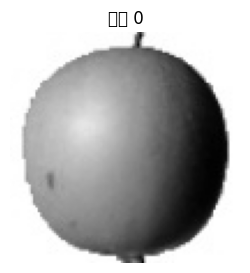

/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 50526 (\N{HANGUL SYLLABLE AP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_462/519179728.py:13: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

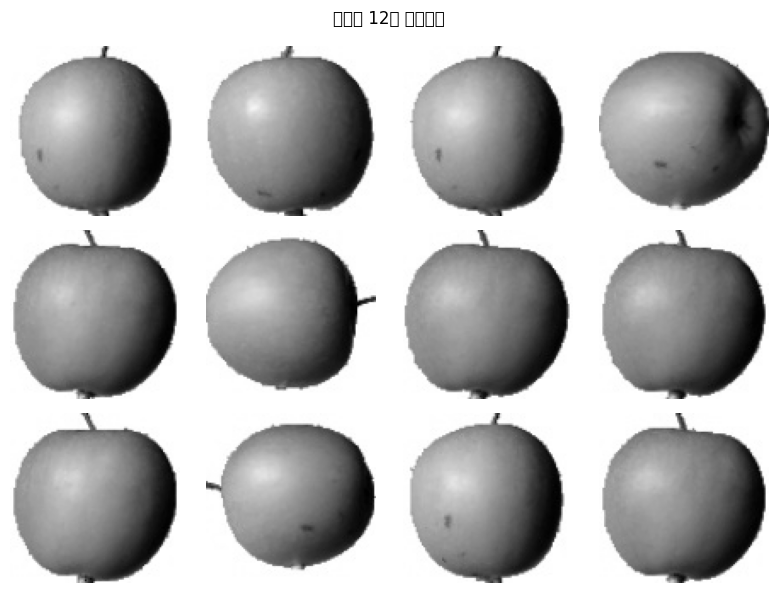

In [6]:
# 3단계 : 데이터를 미리보기
plt.figure(figsize=(3,3))
plt.imshow(fruits[0], cmap="gray_r")
plt.title("샘플 0")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(8,6))
for ax, img in zip(axes.ravel(), fruits[:12]):
    ax.imshow(img, cmap="gray_r")
    ax.axis("off")
plt.suptitle("앞부분 12장 미리보기")
plt.tight_layout()
plt.show()

In [8]:
 # Part A) 원본픽셀 (고차원)으로 K-means 먼저 해보기
X = fruits.reshape(len(fruits), -1)
print("X shape:", X.shape)

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X shape: (300, 10000)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

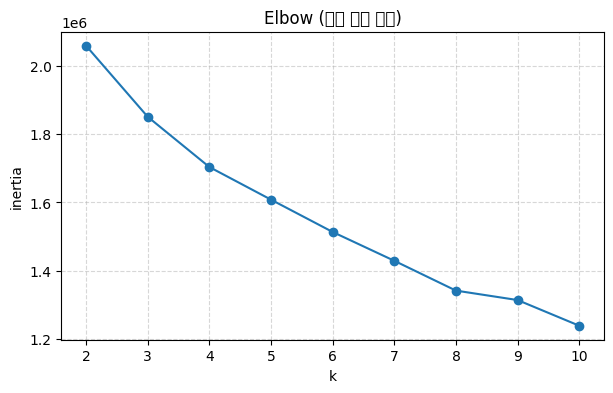

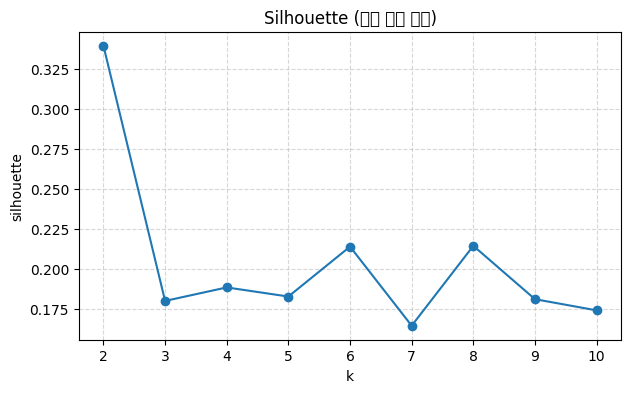

실루엣 기준 추천 k(원본): 2


In [9]:
# 4단계 : k 후보 탐색(엘보+실루엣)
ks = range(2,11)
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters = k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow")
plt.xlabel("k"); plt.ylabel("inertia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), sils, marker="o")
plt.title("Silhouette")
plt.xlabel("k"); plt.ylabel("silhouette")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

best_k_raw = list(ks)[int(np.argmax(sils))]
print("실루엣 기준 추천 k(원본):", best_k_raw)

클러스터별 개수(원본): [202  98]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


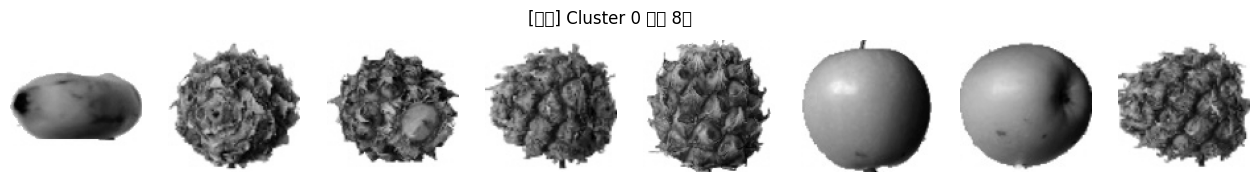

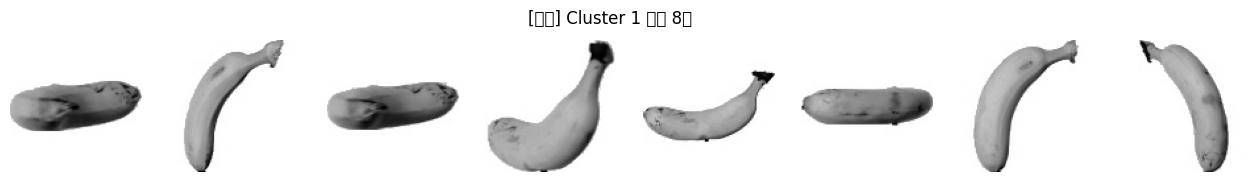

In [12]:
# 5단계 : 최종 R 학습 + 클러스터
k_raw = best_k_raw
kmeans_raw = KMeans(n_clusters=k_raw, n_init=10, random_state=42)
labels_raw = kmeans_raw.fit_predict(X_scaled)

print("클러스터별 개수(원본):", np.bincount(labels_raw))

rng = np.random.default_rng(42)

def show_cluster_samples(labels, cluster_id, n=8, title_prefix=""):
    idx = np.where(labels == cluster_id)[0]
    pick = rng.choice(idx, size=min(n, len(idx)), replace=False)

    fig, axes = plt.subplots(1, len(pick), figsize=(2*len(pick), 2))
    if len(pick) == 1:
        axes = [axes]
    for ax, i in zip(axes, pick):
        ax.imshow(fruits[i], cmap="gray_r")
        ax.axis("off")
    plt.suptitle(f"{title_prefix} Cluster {cluster_id} 샘플 {len(pick)}장")
    plt.show()

for c in range(k_raw):
    show_cluster_samples(labels_raw, c, n=8, title_prefix="[원본]")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

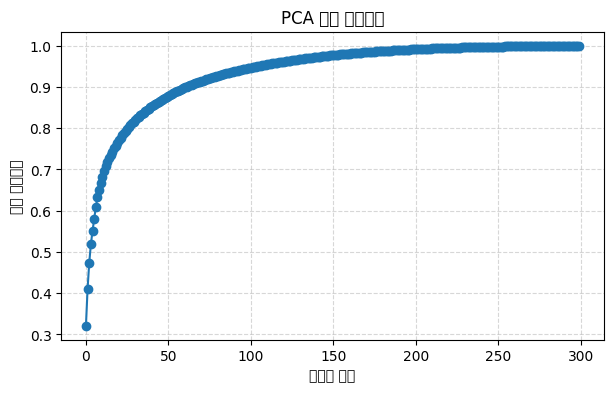

설명분산 95% 만족 주성분 개수: 105


In [13]:
from numpy.random.mtrand import random
# Part B) PCA(주성분분석) 추가: “고차원 → 정보 보존하며 축소”
# 6단계 : PCA로 "설명분산" 확인: 몇 개 PC가 필요할까?

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(7,4))
plt.plot(cum_var,marker="o")
plt.title("PCA 누적 설명분산")
plt.xlabel("주성분 개수"); plt.ylabel("누적 설명분산")
plt.grid(True, linestyle = "--", alpha=0.5)
plt.show()

# 95% 설명분산을 만족하는 최소 주성분 개수
n95 = int(np.argmax(cum_var >= 0.95)+1)
print("설명분산 95% 만족 주성분 개수:", n95)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

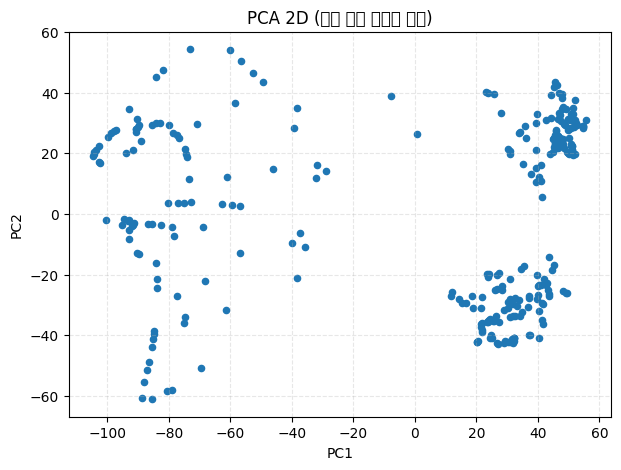

In [14]:
# Part C) PCA 2D/3D 시각화 (군집 “눈으로 보기”)
# 7단계 : PCA 2차원으로 축소 후 시각화
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], s=20)
plt.title("PCA 2D (라벨 없이 데이터 분포)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

X_pca shape: (300, 105)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


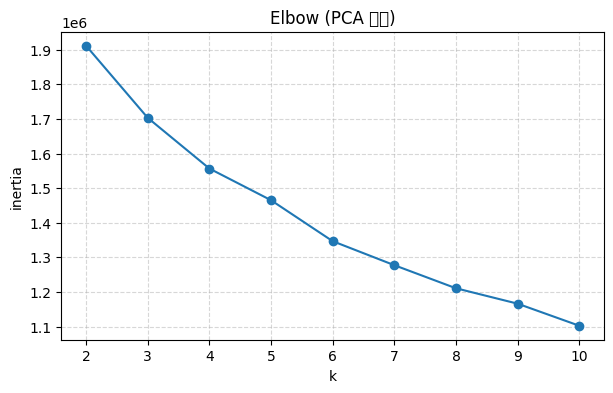

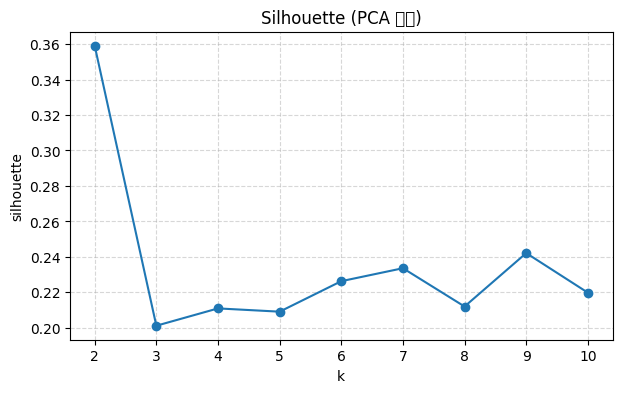

실루엣 기준 추천 k(PCA): 2


In [16]:
# Part D) PCA 공간에서 k-means 다시 해보기 (핵심 연결)
# 8단계 : PCA로 차원 축소(95% 보존 차원) 후 k-means

pca = PCA(n_components=n95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("X_pca shape:", X_pca.shape)

ks = range(2, 11)
inertias_pca, sils_pca = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)

    inertias_pca.append(km.inertia_)
    sils_pca.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias_pca, marker="o")
plt.title("Elbow (PCA 공간)")
plt.xlabel("k"); plt.ylabel("inertia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), sils_pca, marker="o")
plt.title("Silhouette (PCA 공간)")
plt.xlabel("k"); plt.ylabel("silhouette")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

best_k_pca = list(ks)[int(np.argmax(sils_pca))]
print("실루엣 기준 추천 k(PCA):", best_k_pca)

클러스터별 개수(PCA): [202  98]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

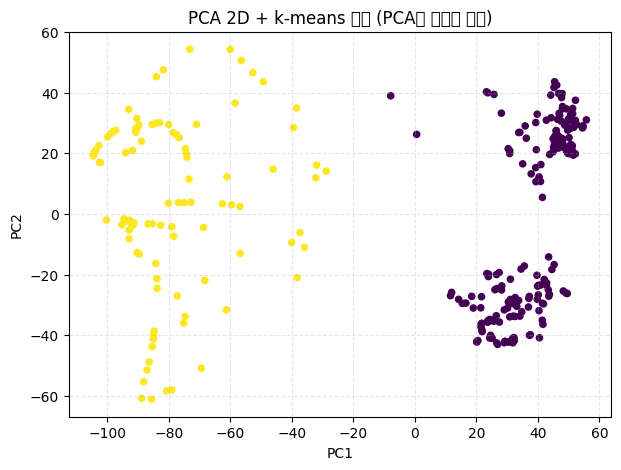

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


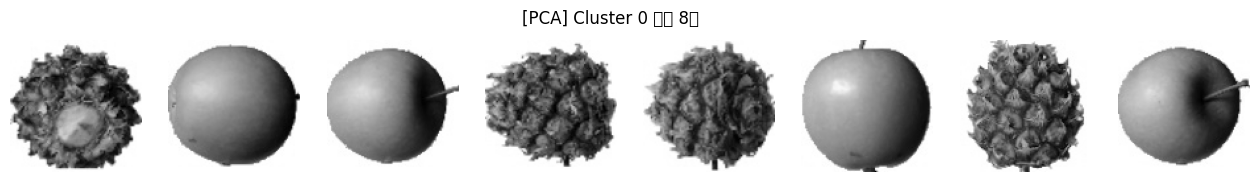

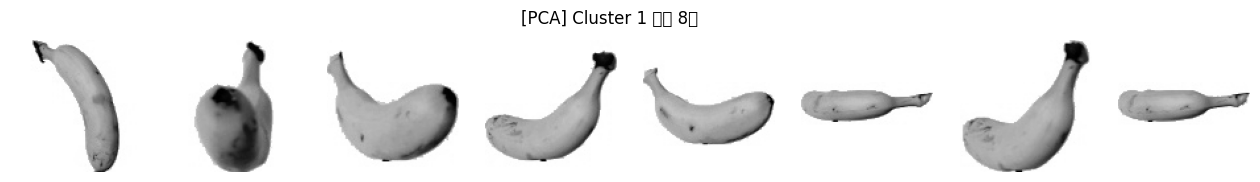

In [17]:
# 9 단계 : PCA 공간 최종 k-means + 2D에 색칠해서 보기

k_pca = best_k_pca
kmeans_pca = KMeans(n_clusters=k_pca, n_init=10, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

print("클러스터별 개수(PCA):", np.bincount(labels_pca))

# PCA 2D(시각화용) 위에 라벨 색칠
plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=labels_pca, s=20)
plt.title("PCA 2D + k-means 라벨 (PCA로 학습한 결과)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

for c in range(k_pca):
    show_cluster_samples(labels_pca, c, n=8, title_prefix="[PCA]")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


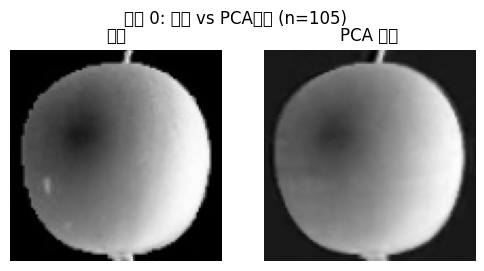

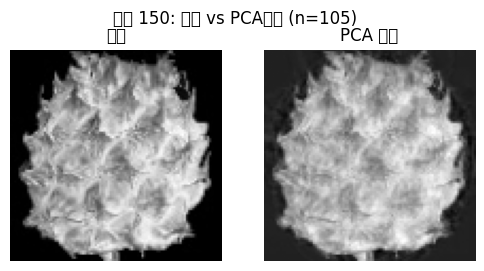

In [19]:
# Part E) (옵션) PCA “복원”으로 정보 손실 체감하기
# 10단계 : PCA 복원 실험: 원본 vs PCA복원 이미지 비교
pca_test = PCA(n_components=n95, random_state=42)
X_red = pca_test.fit_transform(X_scaled)
X_rec = pca_test.inverse_transform(X_red)          # 표준화 공간으로 복원
X_rec = scaler.inverse_transform(X_rec)            # 원본 픽셀 스케일로 복원

def compare_original_recon(i):
    orig = X[i].reshape(H, W)
    recon = X_rec[i].reshape(H, W)

    fig, axes = plt.subplots(1, 2, figsize=(6,3))
    axes[0].imshow(orig, cmap="gray"); axes[0].set_title("원본"); axes[0].axis("off")
    axes[1].imshow(recon, cmap="gray"); axes[1].set_title("PCA 복원"); axes[1].axis("off")
    plt.suptitle(f"샘플 {i}: 원본 vs PCA복원 (n={n95})")
    plt.show()

compare_original_recon(0)
compare_original_recon(150)